# Plot Figure S8A: Overall Regrowth Probability Comparison

## Overview
This notebook generates Figure S8A comparing overall regrowth probabilities between:
- AB homogeneous (wild-type)
- AB gradient

## Analysis Workflow
1. **Load Data**: Import per-chamber regrowth fractions from both conditions
2. **Calculate Statistics**: Perform chi-square test and t-test comparisons
3. **Generate Plot**: Create scatter plot with medians and statistical annotations

## Output
- `S8A_ab_gradient_overall_regrowth_probability.pdf`: Publication-ready figure

In [4]:
# Data analysis and visualization packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats
from scipy.stats import chisquare

# Set Arial font for all text
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42  # Editable text in PDF
matplotlib.rcParams['ps.fonttype'] = 42

# Step 1: Chi-Square Test for Spatial Distribution

## Objective
Test whether the spatial distribution of regrowth differs between AB homogeneous and AB gradient conditions.

## Method
- Compare observed counts (AB homogeneous) vs expected counts (AB gradient)
- Perform chi-square goodness-of-fit test for both x and y axes
- Add pseudocount (0.5) to handle zero bins

In [5]:
# Configuration
b_mean = 148.46  # Normalization factor

# Load per-replicate datasets
real = pd.read_csv('1_regrowth_fractions_ab_gradient_per_replicate.csv')
null = pd.read_csv('../../Figure1/1E/figure_code/1_regrowth_fractions_wt_per_chamber.csv')

# Convert fractions to counts
real['count'] = real['regrowth_fraction'] * b_mean
null['count'] = null['regrowth_fraction'] * b_mean

# Observed totals per bin (summing replicates)
real_observed = (real
                 .groupby(['axis', 'bin_left'], as_index=False)
                 .agg(observed_count=('count', 'sum')))

# Expected counts per bin (averaging across replicates)
null_expected = (null
                 .groupby(['axis', 'bin_left'], as_index=False)
                 .agg(expected_count=('count', 'mean')))

merged = real_observed.merge(null_expected, on=['axis', 'bin_left'])

# Perform chi-square test for each axis
results = []
for axis in ['x', 'y']:
    subset = merged[merged['axis'] == axis].copy()
    observed = subset['observed_count'].to_numpy()
    expected = subset['expected_count'].to_numpy()
    
    # Add pseudocount to handle zeros
    observed = observed + 0.5
    expected = expected + 0.5
    
    # Rescale expected counts to match observed total
    expected *= observed.sum() / expected.sum()
    
    chi2, p = chisquare(f_obs=observed, f_exp=expected)
    
    results.append({
        'axis': axis,
        'chi2': chi2,
        'degrees_of_freedom': len(observed) - 1,
        'p_value': p
    })

print("CHI-SQUARE TEST RESULTS:")
print(pd.DataFrame(results))

# Interpretation
print("\nInterpretation:")
for result in results:
    axis = result['axis']
    chi2 = result['chi2']
    p = result['p_value']
    
    if p < 0.001:
        sig = "*** HIGHLY SIGNIFICANT (p < 0.001)"
    elif p < 0.01:
        sig = "** SIGNIFICANT (p < 0.01)"
    elif p < 0.05:
        sig = "* SIGNIFICANT (p < 0.05)"
    else:
        sig = "not significant (p >= 0.05)"
    
    print(f"{axis.upper()}-axis: χ² = {chi2:.2f}, p = {p:.2e} → {sig}")

CHI-SQUARE TEST RESULTS:
  axis      chi2  degrees_of_freedom   p_value
0    x  0.889262                   9  0.999653
1    y  0.886118                   9  0.999658

Interpretation:
X-axis: χ² = 0.89, p = 1.00e+00 → not significant (p >= 0.05)
Y-axis: χ² = 0.89, p = 1.00e+00 → not significant (p >= 0.05)


# Step 2: T-Test for Overall Regrowth Probability

## Objective
Compare mean regrowth probabilities between AB homogeneous and AB gradient conditions.

## Method
1. Calculate mean regrowth fraction per chamber (averaging across all bins)
2. Check normality with Shapiro-Wilk test
3. Perform Welch's t-test (unequal variances)
4. Visualize results with scatter plot and statistical annotation

In [6]:
# Load per-chamber data
regrowth_chamber_wt = pd.read_csv('../../Figure1/1E/figure_code/1_regrowth_fractions_wt_per_chamber.csv')
regrowth_chamber_HR = pd.read_csv('1_regrowth_fractions_ab_gradient_per_chamber.csv')


# Add strain labels
regrowth_chamber_wt['strain'] = 'AB homogeneous'
regrowth_chamber_HR['strain'] = 'AB gradient'

# Combine
all_data = pd.concat([regrowth_chamber_wt, regrowth_chamber_HR], ignore_index=True)

# Filter for y-axis data
y_data = all_data[all_data['axis'] == 'y'].copy()

# Calculate mean regrowth per chamber
chamber_means = (
    y_data.groupby(['strain', 'replicate', 'position'])['regrowth_fraction']
    .mean()
    .reset_index()
)
chamber_means.columns = ['strain', 'replicate', 'position', 'mean_regrowth_fraction']

strains_order = ['AB homogeneous', 'AB gradient']

# Extract values for statistical tests
wt_vals = chamber_means[chamber_means['strain'] == 'AB homogeneous']['mean_regrowth_fraction'].values
hr_vals = chamber_means[chamber_means['strain'] == 'AB gradient']['mean_regrowth_fraction'].values

# Check normality (prerequisite for t-test)
shapiro_wt = stats.shapiro(wt_vals)
shapiro_hr = stats.shapiro(hr_vals)

print("NORMALITY TEST (Shapiro-Wilk):")
print(f"  AB homogeneous: W={shapiro_wt.statistic:.4f}, p={shapiro_wt.pvalue:.4f}")
print(f"  AB gradient: W={shapiro_hr.statistic:.4f}, p={shapiro_hr.pvalue:.4f}")

# Perform t-test
t_stat, p_val = stats.ttest_ind(wt_vals, hr_vals, equal_var=False)  # Welch's t-test
print("\nT-TEST RESULTS (AB homogeneous vs AB gradient):")
print(f"  t = {t_stat:.4f}, p = {p_val:.4e}")
print(f"  Mean ± SEM:")
print(f"    AB homogeneous = {np.mean(wt_vals):.4f} ± {stats.sem(wt_vals):.4f}")
print(f"    AB gradient = {np.mean(hr_vals):.4f} ± {stats.sem(hr_vals):.4f}")

pvalues_vs_wt = {'AB gradient': p_val}

NORMALITY TEST (Shapiro-Wilk):
  AB homogeneous: W=0.9271, p=0.0945
  AB gradient: W=0.8776, p=0.1225

T-TEST RESULTS (AB homogeneous vs AB gradient):
  t = -0.3972, p = 6.9809e-01
  Mean ± SEM:
    AB homogeneous = 0.0053 ± 0.0008
    AB gradient = 0.0061 ± 0.0019


# Step 3: Generate Figure S8A

## Visualization
- Scatter plot with jittered points for each chamber
- Zero values shown as dashes near y=0
- Non-zero values as circles
- Median indicated by horizontal line
- Statistical significance annotated with asterisks

✅ Figure saved: S8A_ab_gradient_overall_regrowth_probability.pdf


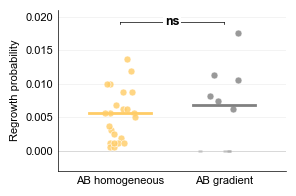

In [7]:
# Define colors
colors = {'AB homogeneous': '#ffcc66', 'AB gradient': 'grey'}

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
x_positions = {strain: i for i, strain in enumerate(strains_order)}

# Set random seed for reproducibility
np.random.seed(42)

# Plot data for each strain
for strain in strains_order:
    strain_data = chamber_means[chamber_means['strain'] == strain]['mean_regrowth_fraction'].values
    x_pos = x_positions[strain]
    
    # Separate zeros and non-zeros
    zeros = strain_data == 0
    non_zeros = strain_data > 0

    # Plot zeros as dashes near y=0
    if zeros.sum() > 0:
        zero_values = strain_data[zeros]
        zero_y = np.random.uniform(-0.00005, 0.00005, len(zero_values))
        zero_jitter = np.random.uniform(-0.25, 0.25, len(zero_values))
        ax.scatter(np.full(len(zero_values), x_pos) + zero_jitter, zero_y, 
                  color=colors[strain], alpha=0.3, s=8, marker='_', 
                  linewidths=2, zorder=1)

    # Plot non-zeros as circles
    if non_zeros.sum() > 0:
        nonzero_values = strain_data[non_zeros]
        nonzero_jitter = np.random.uniform(-0.15, 0.15, len(nonzero_values))
        ax.scatter(np.full(len(nonzero_values), x_pos) + nonzero_jitter, nonzero_values, 
                  color=colors[strain], alpha=0.8, s=25, 
                  edgecolors='white', linewidth=0.5, zorder=3)

    # Plot median
    median_val = np.median(strain_data)
    ax.plot([x_pos - 0.3, x_pos + 0.3], [median_val, median_val], 
           color=colors[strain], linewidth=2, zorder=4)

# Add horizontal line at y=0
ax.axhline(y=0, color='lightgray', linestyle='-', linewidth=0.5, zorder=0)

# Add significance annotation
wt_x, hr_x = x_positions['AB homogeneous'], x_positions['AB gradient']
y_max = chamber_means['mean_regrowth_fraction'].max()
y_pos = y_max * 1.1

# Draw comparison bracket
ax.plot([wt_x, hr_x], [y_pos, y_pos], color='black', linewidth=0.5)
ax.plot([wt_x, wt_x], [y_pos, y_pos - y_max*0.02], color='black', linewidth=0.5)
ax.plot([hr_x, hr_x], [y_pos, y_pos - y_max*0.02], color='black', linewidth=0.5)

# Add significance stars
p = pvalues_vs_wt['AB gradient']
star = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
ax.text((wt_x + hr_x)/2, y_pos, star, ha='center', va='center', 
       fontsize=9, color='black', fontweight='bold',
       bbox=dict(facecolor='white', edgecolor='none', pad=1))

# Formatting
ax.set_xlim(-0.6, len(strains_order) - 0.4)
ax.set_xticks(range(len(strains_order)))
ax.set_xticklabels(strains_order, fontsize=8, rotation=0, ha='center')
ax.set_ylabel('Regrowth probability', fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(width=0.5, length=0, labelsize=8)
ax.grid(axis='y', alpha=0.2, linestyle='-', linewidth=0.5)
ax.set_ylim(-0.003, y_max*1.2)

plt.tight_layout()

# Save figure
output_pdf = 'S8A_ab_gradient_overall_regrowth_probability.pdf'
plt.savefig(output_pdf, dpi=300, bbox_inches='tight')
print(f"✅ Figure saved: {output_pdf}")
plt.show()